Declare a numba accelerated function that computes the Halton QRNG
1. The parameter $n$ is an integer of any size
2. The parameter $p$ is a prime number

In [1]:
"""mc_high_dimensions.ipynb"""

# Cell 01

from numba import float64, int64, vectorize


@vectorize([float64(int64, int64)], nopython=True)
def halton(n, p):
    h, f = 0, 1
    while n > 0:
        f = f / p
        h += (n % p) * f
        n = int(n / p)
    return h


print(halton(10_000, 2))

0.03472900390625


Set the total number of samples to take

In [2]:
# Cell 02

total_dots = 6_250_000

print(f"{total_dots = :,}")

total_dots = 6,250,000


Estimate the content of `n-balls` from dimension 1 to 12
1. Use `sympy` to provide the Halton generator the correct prime number for each successive dimension
2. We only need to keep a single accumulating $d$ value to represent the\
   distance to the origin for each point as we add each additional dimension
3. The Monte Carlo sample space multiplier grows by $2^{dimension}$

In [3]:
# Cell 03

import numpy as np
import sympy

dimensions = 13
d = np.zeros(total_dots)
est = np.zeros(dimensions)
est[0] = 1  # By definition
est[1] = 2  # The 1-D line in the interval [-1,1] has "area" (length) 2

for dim in np.arange(1, dimensions):
    print(f"Calculating the volume of a unit {dim:>2}-ball . . .")
    v = halton(np.arange(total_dots), sympy.prime(dim)) * 2 - 1
    d += v**2
    est[dim] = 2**dim * np.count_nonzero(np.sqrt(d) <= 1.0) / total_dots

Calculating the volume of a unit  1-ball . . .
Calculating the volume of a unit  2-ball . . .
Calculating the volume of a unit  3-ball . . .
Calculating the volume of a unit  4-ball . . .
Calculating the volume of a unit  5-ball . . .
Calculating the volume of a unit  6-ball . . .
Calculating the volume of a unit  7-ball . . .
Calculating the volume of a unit  8-ball . . .
Calculating the volume of a unit  9-ball . . .
Calculating the volume of a unit 10-ball . . .
Calculating the volume of a unit 11-ball . . .
Calculating the volume of a unit 12-ball . . .


Using the analytic solution, calculate the dimension and content for the <u>largest</u> unit `n-ball`

$V_{n}\left( R\right)=\dfrac{\pi^{\frac{n}{2}}R^n}{\Gamma{\left(\frac{n}{2}+1\right)}}$

In [4]:
# Cell 04

from scipy.signal import find_peaks
from scipy.special import gamma

act_x = np.linspace(0, dimensions - 1, 1000)
act_y = np.power(np.pi, act_x / 2) / gamma(act_x / 2 + 1)
m = find_peaks(act_y)[0][0]
print(f"max dim = {act_x[m]:.6f}")
print(f"max vol = {act_y[m]:.6f}")

max dim = 5.261261
max vol = 5.277764


Plot the estimated and actual `n-ball` content vs. dimension

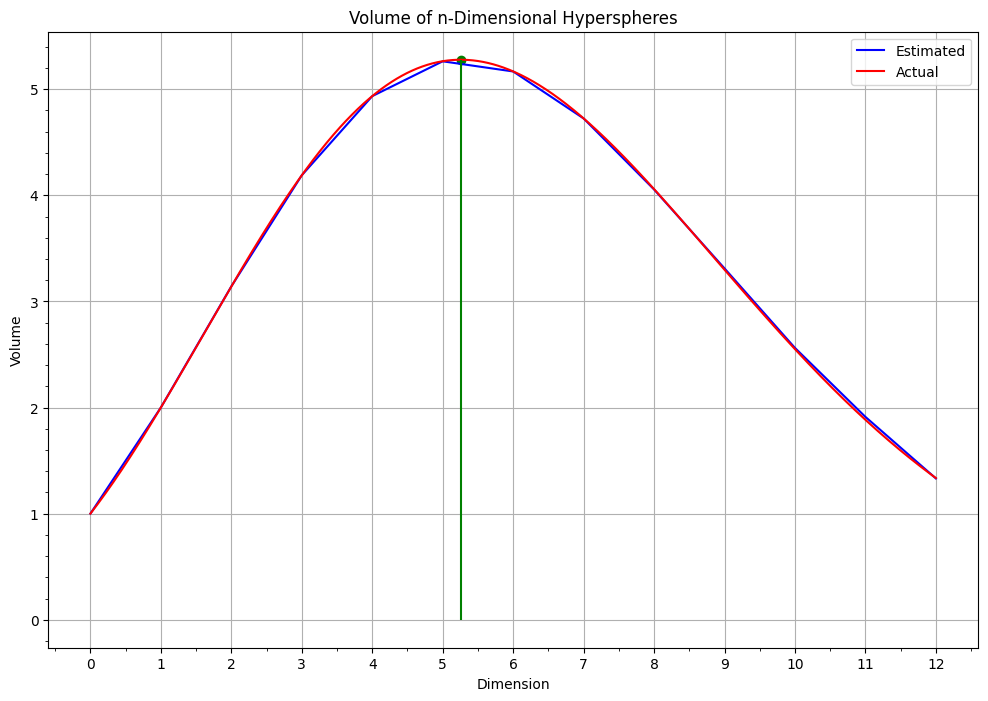

In [5]:
# Cell 05

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

plt.figure(figsize=(12, 8))
plt.plot(np.arange(dimensions), est, color="blue", label="Estimated")
plt.plot(act_x, act_y, color="red", label="Actual")
plt.scatter(act_x[m], act_y[m], marker="o", color="green")
plt.vlines(act_x[m], 0, act_y[m], color="green")
plt.title("Volume of n-Dimensional Hyperspheres")
plt.xlabel("Dimension")
plt.ylabel("Volume")
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc="upper right")
ax.grid("on")
plt.show()